In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
df_train = pd.read_csv("../data/cleaned/train_data.csv")

Plotting Class Imbalance...


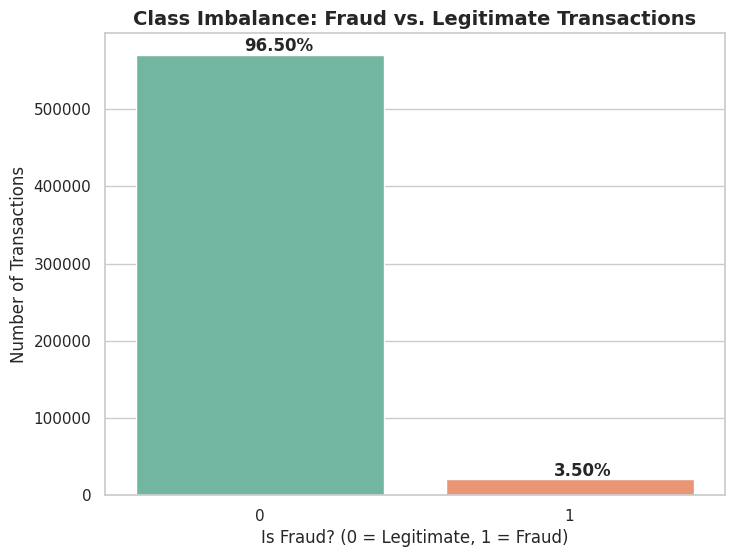

In [4]:
print("Plotting Class Imbalance...")

# Set a clean, professional theme for the paper
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Create the count plot
ax = sns.countplot(x='isFraud', hue="isFraud", data=df_train, palette='Set2', legend=False)

# Add titles and labels
plt.title('Class Imbalance: Fraud vs. Legitimate Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Is Fraud? (0 = Legitimate, 1 = Fraud)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Calculate and annotate the percentages on top of the bars
total = len(df_train)
for p in ax.patches:
    # Calculate percentage
    percentage = f'{100 * p.get_height() / total:.2f}%'
    # Find the center of the bar for x-coordinate
    x = p.get_x() + p.get_width() / 2 - 0.05
    # Find the top of the bar for y-ccoordinate, add a little padding
    y = p.get_height() + 5000 
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')

plt.show()

Plotting Correlation Heatmap...


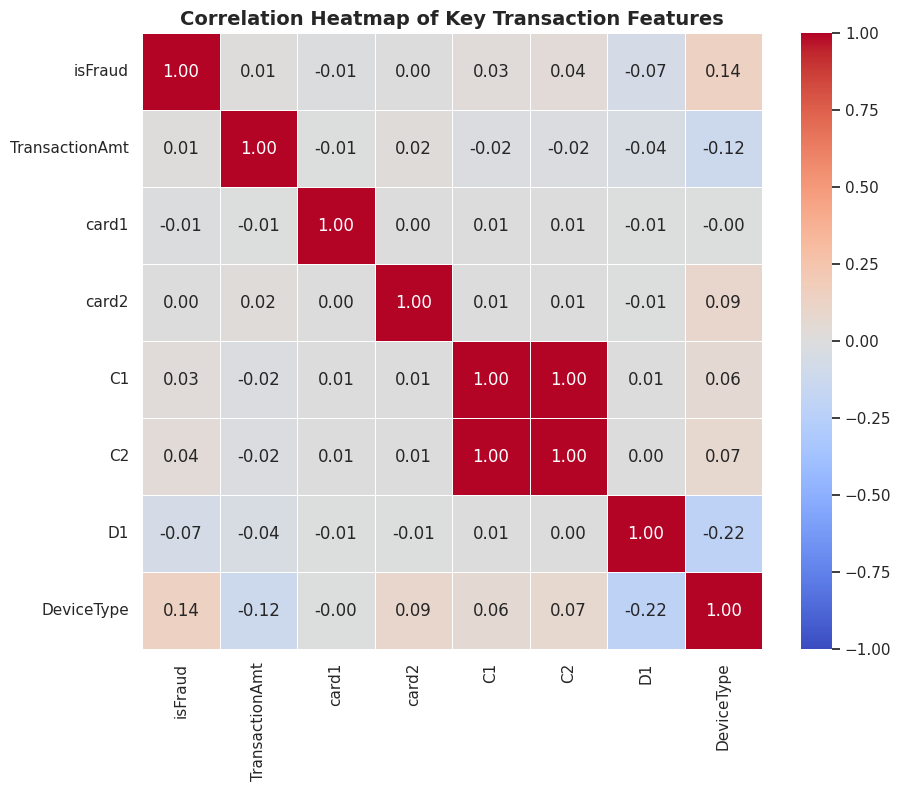

In [5]:
print("Plotting Correlation Heatmap...")

# 1. Select a targeted subset of features to keep the plot readable
subset_cols = [
    'isFraud', 'TransactionAmt', 'card1', 'card2', 
    'C1', 'C2', 'D1', 'DeviceType'
]

plt.figure(figsize=(10, 8))

# 2. Calculate the correlation matrix only for these columns
corr_matrix = df_train[subset_cols].corr()

# 3. Plot the heatmap
# annot=True puts the actual numbers in the boxes
# cmap='coolwarm' makes strong negative correlations blue and strong positive ones red
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Key Transaction Features', fontsize=14, fontweight='bold')
plt.show()